# Track-A · Part-1 — Linear Algebra for AI PMs
### `Track-A_Part-1_Linear_algebra_1.ipynb`

**Expected time:** 60–90 minutes

**Where:** Google Colab (free tier is plenty; CPU is fine)

**What you'll build, in 7 parts:**

1. Vectors, matrices, tensors — and the #1 practical skill: **shapes**
2. The **dot product**, by hand (the most important operation in AI)
3. **Cosine similarity** from scratch — and where it disagrees with Euclidean distance
4. **Matrix multiplication**, a deliberate *dimension-mismatch* error, and `y = Wx + b`
5. **Real embeddings** — 10 sentences → a similarity heatmap
6. **Nearest-neighbor search** — the core of RAG retrieval, in ~15 lines
7. *Stretch:* **PCA** — squash 384 dimensions into 2 and watch topics cluster

**How to use this notebook:** run cells top-to-bottom (`Shift+Enter`). Every part starts with a short recap and — where marked — a **CHECKPOINT**: predict the answer *before* running. That prediction step is where the learning happens.

> From the Track-A_Part-1: Core concept: *modern AI turns things into vectors, then does two operations over and over — measuring angles between them (similarity) and transforming them (matrix multiplication). This notebook makes you do both with your own hands.*

In [1]:
# ── Setup (Parts 1–4 need only NumPy — already installed everywhere) ──
import numpy as np

np.set_printoptions(precision=3, suppress=True)
print("NumPy ready, version:", np.__version__)

NumPy ready, version: 2.0.2


---
## Vectors, matrices, tensors & shapes

**Recap:** these are boxes of increasing dimension — same numbers, more structure.
- **Scalar** (rank-0): one number.
- **Vector** (rank-1): an ordered list — a *point* in space AND an *arrow* from the origin.
- **Matrix** (rank-2): a grid — either a *stack of vectors* (data) or a *transformation* (machine).
- **Tensor** (rank-3+): just more axes.

**Shapes** are the #1 practical skill: every ML debugging conversation starts with *“what's the shape?”*

### ✋ CHECKPOINT — before running the next cell, predict the `.shape` of each object:
1. `temperature` (a scalar wrapped in `np.array`)
2. `die_hard` = `[9, 1]`
3. `movie_matrix` = 3 movies stacked as rows
4. `toy_tensor` = 2 “images” of 4×3

Write your four predictions down, then run.

In [2]:
# ── 1a. Create scalar → vector → matrix → tensor, inspect .shape ──

# SCALAR — rank-0: one number
temperature = np.array(23.5)

# VECTORS — rank-1: the movie example you'll reuse all week: [action, romance]
die_hard   = np.array([9, 1])   # almost pure action
notebook   = np.array([1, 9])   # almost pure romance
mr_mrs     = np.array([7, 6])   # both

# ...and a customer as a vector: [avg_order_value, orders_per_month, months_since_signup]
customer_A = np.array([1200, 3, 14])

# MATRIX — rank-2: a STACK of vectors. Rows = items, columns = dimensions.
movie_matrix = np.array([die_hard, notebook, mr_mrs])

# TENSOR — rank-3: 2 tiny "images", each 4 pixels tall × 3 wide.
# (A real LLM activation tensor has a shape like (8 requests × 2048 tokens × 4096 dims)
#  — same idea, big enough to fill a GPU. We stay tiny.)
toy_tensor = np.zeros((2, 4, 3))

for name, obj in [("temperature", temperature), ("die_hard", die_hard),
                  ("customer_A", customer_A), ("movie_matrix", movie_matrix),
                  ("toy_tensor", toy_tensor)]:
    print(f"{name:14s} shape = {str(obj.shape):12s} rank = {obj.ndim}")

# How did your four predictions do?
# Note: a scalar's shape prints as () — rank 0, zero axes. That's not a bug.

temperature    shape = ()           rank = 0
die_hard       shape = (2,)         rank = 1
customer_A     shape = (3,)         rank = 1
movie_matrix   shape = (3, 2)       rank = 2
toy_tensor     shape = (2, 4, 3)    rank = 3


### ✋ CHECKPOINT — transpose & reshape
`A` below is (3×4). Predict, before running:
1. `A.T`'s shape
2. `v.reshape(2, 3)`'s shape — and *which numbers end up in row 0*
3. What `reshape(4, 2)` on a 6-element vector will do

In [3]:
# ── 1b. Transpose and reshaping ──

A = np.arange(12).reshape(3, 4)   # a (3×4) matrix filled with 0..11
print("A, shape", A.shape, ":\n", A)

# TRANSPOSE flips rows ↔ columns: (3×4) → (4×3).
# It exists mostly to make shapes line up.
print("\nA.T, shape", A.T.shape, ":\n", A.T)

# RESHAPE re-boxes the same numbers into a new shape (size must match!):
v = np.array([1, 2, 3, 4, 5, 6])          # shape (6,)
print("\nv reshaped to (2,3):\n", v.reshape(2, 3))
print("\nv reshaped to (3,2):\n", v.reshape(3, 2))

# And the failure case — 6 numbers cannot fill a (4×2)=8 box:
try:
    v.reshape(4, 2)
except ValueError as e:
    print("\nreshape(4,2) failed, as predicted →", e)

# Self-check (these run silently if you're right):
assert A.T.shape == (4, 3)
assert v.reshape(2, 3)[0].tolist() == [1, 2, 3]
print("\n✅ Part 1 checks passed")

A, shape (3, 4) :
 [[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]

A.T, shape (4, 3) :
 [[ 0  4  8]
 [ 1  5  9]
 [ 2  6 10]
 [ 3  7 11]]

v reshaped to (2,3):
 [[1 2 3]
 [4 5 6]]

v reshaped to (3,2):
 [[1 2]
 [3 4]
 [5 6]]

reshape(4,2) failed, as predicted → cannot reshape array of size 6 into shape (4,2)

✅ Part 1 checks passed


---
## Part 2 — The dot product, by hand

**Recap — one operation, two equivalent faces:**
- *Algebra:* `a · b = Σ aᵢbᵢ` — multiply matching positions, add up.
- *Geometry:* `a · b = |a||b|cos(θ)` — lengths × angle-alignment.

**The intuition:** an **alignment score** between two arrows.

Large positive = same direction;

zero = perpendicular (*orthogonal*);

negative = opposing.

You'll implement it with a plain Python loop first — so you *feel* that it's just multiply-and-add — then verify against `np.dot`.

In [4]:
# ── 2. Dot product: manual loop vs np.dot ──

# THE SHOPPING-CART INTUITION:
#   push a cart in the direction it faces → full effect   (max dot product)
#   push it sideways                      → nothing        (zero / orthogonal)
#   push it backwards                     → negative
# The dot product measures "how much of your effort counts."

def manual_dot(a, b):
    """Dot product with a plain loop: multiply matching positions, add up."""
    assert len(a) == len(b), "vectors must be the same length"
    total = 0
    for i in range(len(a)):
        total += a[i] * b[i]
    return total

# Verify our loop against NumPy on the movie vectors:
print("manual_dot(die_hard, mr_mrs) =", manual_dot(die_hard, mr_mrs))
print("np.dot    (die_hard, mr_mrs) =", np.dot(die_hard, mr_mrs))
assert manual_dot(die_hard, mr_mrs) == np.dot(die_hard, mr_mrs)

# ── The movie example from the slides ──
print()
print("Die Hard · Mr.&Mrs.Smith = [9,1]·[7,6] = 63 + 6 =", np.dot(die_hard, mr_mrs),
      "  ← high: both action-heavy")
print("Die Hard · The Notebook  = [9,1]·[1,9] =  9 + 9 =", np.dot(die_hard, notebook),
      "  ← low: different genres")

assert np.dot(die_hard, mr_mrs) == 69      # the number from the lecture
assert np.dot(die_hard, notebook) == 18
print("\n✅ Part 2 checks passed — no magic: multiply and add.")

manual_dot(die_hard, mr_mrs) = 69
np.dot    (die_hard, mr_mrs) = 69

Die Hard · Mr.&Mrs.Smith = [9,1]·[7,6] = 63 + 6 = 69   ← high: both action-heavy
Die Hard · The Notebook  = [9,1]·[1,9] =  9 + 9 = 18   ← low: different genres

✅ Part 2 checks passed — no magic: multiply and add.


---
## Part 3 — Cosine similarity from scratch (vs Euclidean distance)

**Recap:**
- **Cosine similarity** = the dot product after ignoring lengths = `(a·b)/(|a||b|)`. Range [−1, +1]. Asks: *“do these arrows point the same way?”* — direction only.
- **Euclidean (L2) distance** = `√(Σ(aᵢ−bᵢ)²)` — straight-line distance. Asks: *“how far apart are the points?”* — magnitude matters.

You'll build cosine yourself, verify against scikit-learn, then reproduce the **disagreement example** — the one that explains why text search uses cosine.

In [5]:
# ── 3a. cosine_similarity from scratch, verified against sklearn ──

def norm(a):
    """Vector length: |a| = sqrt(sum of squares)."""
    return np.sqrt(np.sum(np.asarray(a, dtype=float) ** 2))

def cosine_similarity_scratch(a, b):
    """cos(a,b) = (a·b) / (|a||b|)"""
    return np.dot(a, b) / (norm(a) * norm(b))

# The classic worked example — do it by hand once, ever:
a = np.array([1, 2, 2])
b = np.array([2, 1, 2])
print("a·b    =", np.dot(a, b))                      # 1·2 + 2·1 + 2·2 = 8
print("|a|    =", norm(a), "  |b| =", norm(b))       # both 3
print("cosine =", cosine_similarity_scratch(a, b))   # 8/9 ≈ 0.889 → highly similar

# Verify against scikit-learn (it expects 2-D arrays: rows = items):
from sklearn.metrics.pairwise import cosine_similarity as sk_cosine
sk_value = sk_cosine(a.reshape(1, -1), b.reshape(1, -1))[0, 0]
print("sklearn:", sk_value)
assert np.isclose(cosine_similarity_scratch(a, b), sk_value)
print("\n✅ our implementation matches scikit-learn")

a·b    = 8
|a|    = 3.0   |b| = 3.0
cosine = 0.8888888888888888
sklearn: 0.8888888888888888

✅ our implementation matches scikit-learn


In [6]:
# ── 3b. When cosine and Euclidean DISAGREE — the example that makes it click ──

def euclidean_distance(a, b):
    """L2(a,b) = sqrt(sum of squared differences)"""
    a, b = np.asarray(a, dtype=float), np.asarray(b, dtype=float)
    return np.sqrt(np.sum((a - b) ** 2))

a = np.array([2,  2])   # a SHORT document about "pricing"
b = np.array([8,  8])   # a LONG  document about "pricing" (same topic, 4x the words/intensity)
c = np.array([2, -2])   # a document about something else entirely

print(f"{'pair':10s} {'cosine':>8s} {'L2 dist':>9s}")
print("-" * 30)
for name, u, v in [("a vs b", a, b), ("a vs c", a, c)]:
    print(f"{name:10s} {cosine_similarity_scratch(u, v):8.2f} {euclidean_distance(u, v):9.2f}")

print("""
Read the table:
  cosine(a,b) = 1.0   → identical direction — SAME TOPIC, despite different lengths
  L2(a,b)     ≈ 8.49  → "far apart" — only because b is bigger
  cosine(a,c) = 0.0   → orthogonal — unrelated
  L2(a,c)     = 4.0   → ...CLOSER than b! Misleading for topic search.

By Euclidean distance the UNRELATED document c looks closer to a than the
same-topic document b. That is exactly why text search uses cosine:
you want "same topic," not "same length."
""")

pair         cosine   L2 dist
------------------------------
a vs b         1.00      8.49
a vs c         0.00      4.00

Read the table:
  cosine(a,b) = 1.0   → identical direction — SAME TOPIC, despite different lengths
  L2(a,b)     ≈ 8.49  → "far apart" — only because b is bigger
  cosine(a,c) = 0.0   → orthogonal — unrelated
  L2(a,c)     = 4.0   → ...CLOSER than b! Misleading for topic search.

By Euclidean distance the UNRELATED document c looks closer to a than the
same-topic document b. That is exactly why text search uses cosine:
you want "same topic," not "same length."



---
## Part 4 — Matrix multiplication, a deliberate error, and `y = Wx + b`

**Recap:** every cell of a matrix product = one dot product (row of A · column of B).
Shapes: `(m×n)·(n×p) → (m×p)` — **inner numbers must match, they “cancel.”**

You'll (1) verify the shape rule, (2) **trigger a dimension-mismatch error on purpose** — the most common ML error in existence — and (3) compute the tiny `y = Wx + b` from the lecture.

In [7]:
# ── 4a. The shape rule: (3×4)·(4×2) → (3×2) ──

P = np.arange(12).reshape(3, 4)     # (3×4)
Q = np.arange(8).reshape(4, 2)      # (4×2)

R = P @ Q                           # '@' is matrix multiplication in Python
print("P", P.shape, "·", "Q", Q.shape, "→", "R", R.shape)
assert R.shape == (3, 2)
print("✅ inner 4s cancelled; outer (3, 2) remained\n")
print(R)

P (3, 4) · Q (4, 2) → R (3, 2)
✅ inner 4s cancelled; outer (3, 2) remained

[[ 28  34]
 [ 76  98]
 [124 162]]


In [8]:
# ── 4b. Now BREAK it on purpose — trigger a dimension mismatch and READ the message ──

bad = np.arange(8).reshape(2, 4)    # (2×4) — inner numbers won't match: (3×4)·(2×4)

try:
    P @ bad
except ValueError as e:
    print("💥 The most common ML error in existence:\n")
    print("   ", e)

# Decode it: "size 4 is different from 2" — the inner edges don't line up.
# When an engineer says "dimension mismatch," THIS message (or its PyTorch cousin)
# is what they're looking at. Usual causes: wrong embedding size, wrong batch
# shape, or a model swap that changed output dimensions.

💥 The most common ML error in existence:

    matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 2 is different from 4)


In [9]:
# ── 4c. y = Wx + b — the most famous equation in deep learning, by hand ──

W = np.array([[1, 0, 2],
              [0, 1, 1]])           # (2×3) weight matrix
x = np.array([10, 20, 30])          # (3,)  input vector
b = np.array([1, 5])                # (2,)  bias vector

Wx = W @ x
y  = Wx + b

print("Step 1 — Wx:")
print("  row 1: 1·10 + 0·20 + 2·30 =", W[0] @ x)
print("  row 2: 0·10 + 1·20 + 1·30 =", W[1] @ x)
print("  Wx =", Wx)
print("Step 2 — add b:")
print("  y = Wx + b =", y)

assert y.tolist() == [71, 55]       # the numbers from the lecture
print("\n✅ A 3-number input became a 2-number output: (2×3)·(3×1)+(2×1) → (2×1).")
print("   That's what ONE neural layer does — millions of times, with learned W.")

Step 1 — Wx:
  row 1: 1·10 + 0·20 + 2·30 = 70
  row 2: 0·10 + 1·20 + 1·30 = 50
  Wx = [70 50]
Step 2 — add b:
  y = Wx + b = [71 55]

✅ A 3-number input became a 2-number output: (2×3)·(3×1)+(2×1) → (2×1).
   That's what ONE neural layer does — millions of times, with learned W.


---
## Part 5 — Real embeddings: 10 sentences → similarity heatmap 🔥

Now the toy `[action, romance]` vectors become the real thing: a free embedding model (`all-MiniLM-L6-v2`, 384 dimensions, runs on CPU) turns sentences into vectors — and cosine similarity finds the topics *with no labels, no rules, no keywords*.

**This heatmap is your lecture's money shot.**

> The install below takes ~1–2 minutes the first time it runs. The model itself is ~80 MB.

In [10]:
# ── 5a. Install + load the embedding model (one-time, ~1–2 min on Colab) ──
%pip install -q sentence-transformers

from sentence_transformers import SentenceTransformer
model = SentenceTransformer("all-MiniLM-L6-v2")   # free, small, CPU-friendly
print("Model loaded. Embedding dimension:", model.get_sentence_embedding_dimension())

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Model loaded. Embedding dimension: 384


/tmp/ipykernel_531/3911491764.py:6: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  print("Model loaded. Embedding dimension:", model.get_sentence_embedding_dimension())


In [11]:
# ── 5b. Embed 10 sentences across 3 topics ──

sentences = [
    # topic: pricing (0–3)
    "Our premium plan costs $49 per month with unlimited seats.",
    "The enterprise tier includes a discount for annual billing.",
    "You can upgrade or downgrade your subscription plan at any time.",
    "Refunds are processed within five business days of cancellation.",
    # topic: cricket (4–6)
    "Virat Kohli scored a brilliant century in the final match.",
    "The bowler took five wickets in a single innings at Eden Gardens.",
    "India won the T20 World Cup after a thrilling last over.",
    # topic: cooking (7–9)
    "Simmer the tomato gravy on low heat for twenty minutes.",
    "Add two tablespoons of butter to make the dal extra creamy.",
    "Buying saffron can cost more than the rest of the dish combined.",  # ← note the word "cost"! (see Part 6)
]
topics = ["pricing"]*4 + ["cricket"]*3 + ["cooking"]*3

# normalize_embeddings=True → every vector has length 1,
# so cosine similarity is JUST a dot product (the "fake-debate insurance" from the lecture).
emb = model.encode(sentences, normalize_embeddings=True)
print("Embeddings shape:", emb.shape, " ← 10 sentences × 384 learned dimensions")

# 10×10 cosine-similarity matrix in ONE matrix multiplication:
# (10×384) · (384×10) → (10×10). Part 4's shape rule, working for a living.
S = emb @ emb.T
print("Similarity matrix shape:", S.shape)

Embeddings shape: (10, 384)  ← 10 sentences × 384 learned dimensions
Similarity matrix shape: (10, 10)


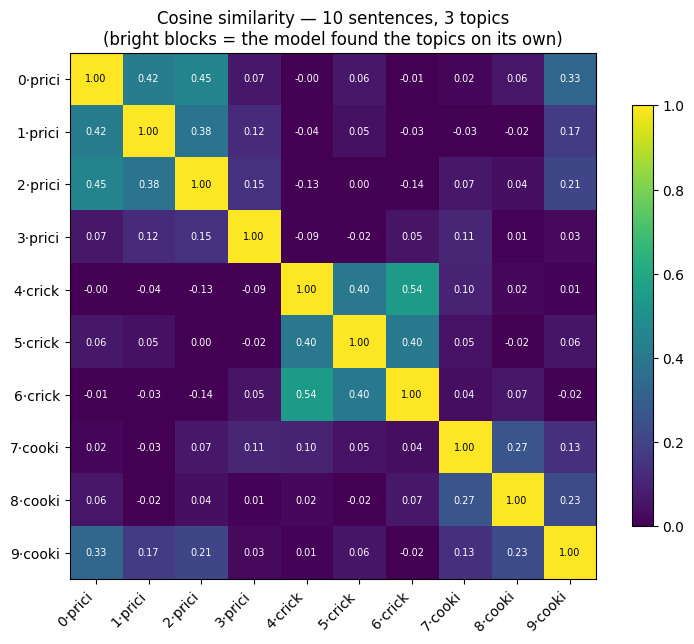

Look for THREE bright blocks on the diagonal: pricing (0–3), cricket (4–6), cooking (7–9).
Nobody told the model these topics exist. That's 'meaning as geometry.'


In [12]:
# ── 5c. The money shot: heatmap of the 10×10 similarity matrix ──
import matplotlib.pyplot as plt

labels = [f"{i}·{t[:5]}" for i, t in enumerate(topics)]

fig, ax = plt.subplots(figsize=(8, 6.5))
im = ax.imshow(S, cmap="viridis", vmin=0, vmax=1)
ax.set_xticks(range(10)); ax.set_xticklabels(labels, rotation=45, ha="right")
ax.set_yticks(range(10)); ax.set_yticklabels(labels)
for i in range(10):
    for j in range(10):
        ax.text(j, i, f"{S[i,j]:.2f}", ha="center", va="center",
                color="white" if S[i,j] < 0.6 else "black", fontsize=7)
ax.set_title("Cosine similarity — 10 sentences, 3 topics\n(bright blocks = the model found the topics on its own)")
fig.colorbar(im, shrink=0.8)
plt.tight_layout()
plt.show()

print("Look for THREE bright blocks on the diagonal: pricing (0–3), cricket (4–6), cooking (7–9).")
print("Nobody told the model these topics exist. That's 'meaning as geometry.'")

---
## Part 6 — Nearest-neighbor search: the core of RAG, in ~15 lines

Given a **query**, rank all 10 sentences by cosine similarity. This is *literally* what a vector database does inside every RAG pipeline: embed the query → dot product against every document → return the top matches.

In [14]:
# ── 6. Rank all sentences against a query ──

query = "how much does the premium plan cost?"

q = model.encode([query], normalize_embeddings=True)[0]   # embed the query → (384,)
scores = emb @ q                                          # (10×384)·(384,) → 10 scores

ranking = np.argsort(scores)[::-1]                        # indices, best first

print(f"Query: “{query}”\n")
print(f"{'rank':>4s}  {'score':>6s}  {'topic':8s} sentence")
print("-" * 95)
for rank, idx in enumerate(ranking, 1):
    flag = "  ⚠️" if topics[idx] != "pricing" and "cost" in sentences[idx] else ""
    print(f"{rank:>4d}  {scores[idx]:6.3f}  {topics[idx]:8s} {sentences[idx]}{flag}")

print("""
You just built the core of RAG retrieval: embed → dot product → rank.

⚠️ Now find the saffron sentence (cooking, but it contains the word "cost").
Notice where it ranks — typically above the other cricket/cooking sentences,
sometimes uncomfortably close to real pricing docs. The embedding model is
pulled by surface vocabulary, not just topic. THAT near-miss — retrieval
that's almost right — is an opening problem for a future topic
(chunking, rerankers, domain-tuned embeddings).
""")

Query: “how much does the premium plan cost?”

rank   score  topic    sentence
-----------------------------------------------------------------------------------------------
   1   0.751  pricing  Our premium plan costs $49 per month with unlimited seats.
   2   0.468  pricing  The enterprise tier includes a discount for annual billing.
   3   0.453  pricing  You can upgrade or downgrade your subscription plan at any time.
   4   0.235  cooking  Buying saffron can cost more than the rest of the dish combined.  ⚠️
   5   0.099  pricing  Refunds are processed within five business days of cancellation.
   6   0.064  cricket  The bowler took five wickets in a single innings at Eden Gardens.
   7   0.018  cooking  Simmer the tomato gravy on low heat for twenty minutes.
   8  -0.003  cooking  Add two tablespoons of butter to make the dal extra creamy.
   9  -0.026  cricket  Virat Kohli scored a brilliant century in the final match.
  10  -0.056  cricket  India won the T20 World Cup after a 

---
## Part 7 (stretch) — PCA: 384 dimensions → 2, clusters made visible

**Concept 5 in action:** PCA keeps the *most informative directions* and drops near-redundant ones — exactly the trade-off behind “can we cut embedding dimensions to reduce vector-DB cost?” (Matryoshka embeddings, PCA). Here we squash 384 → 2 just so we can *see* the space.

Reduced shape: (10, 2)
Variance kept by 2 of 384 directions: 42%


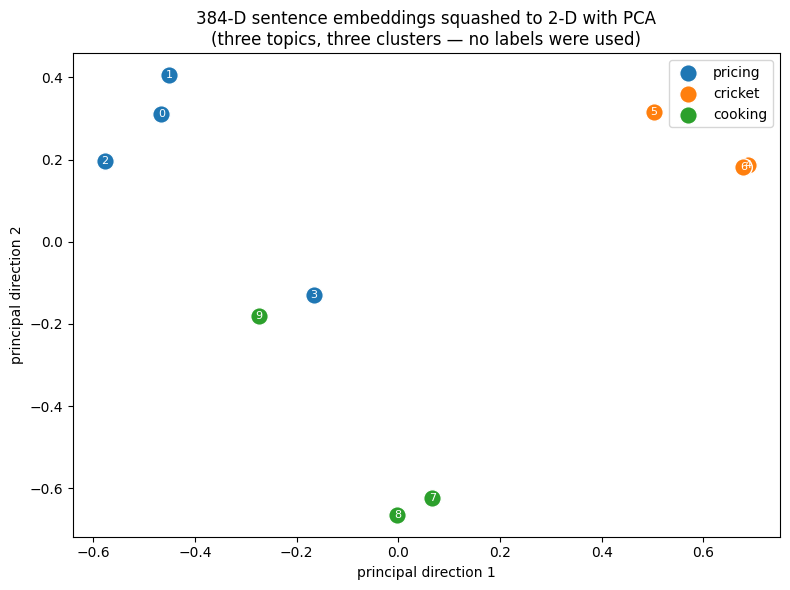

Even keeping just 2 of 384 directions, the topic clusters survive —
that's why dimension reduction is a real cost lever (Matryoshka / PCA),
and why the trade-off must be MEASURED (what recall do we lose?) — Future Topic: evals.


In [16]:
# ── 7. PCA to 2-D and scatter-plot the clusters ──
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
emb_2d = pca.fit_transform(emb)               # (10×384) → (10×2)
print("Reduced shape:", emb_2d.shape)
print(f"Variance kept by 2 of 384 directions: {pca.explained_variance_ratio_.sum():.0%}")

colors = {"pricing": "tab:blue", "cricket": "tab:orange", "cooking": "tab:green"}

fig, ax = plt.subplots(figsize=(8, 6))
for topic in colors:
    idxs = [i for i, t in enumerate(topics) if t == topic]
    ax.scatter(emb_2d[idxs, 0], emb_2d[idxs, 1], s=160,
               c=colors[topic], label=topic, edgecolors="white")
    for i in idxs:
        ax.annotate(str(i), (emb_2d[i, 0], emb_2d[i, 1]),
                    ha="center", va="center", fontsize=8, color="white")
ax.legend()
ax.set_title("384-D sentence embeddings squashed to 2-D with PCA\n(three topics, three clusters — no labels were used)")
ax.set_xlabel("principal direction 1"); ax.set_ylabel("principal direction 2")
plt.tight_layout()
plt.show()

print("Even keeping just 2 of 384 directions, the topic clusters survive —")
print("that's why dimension reduction is a real cost lever (Matryoshka / PCA),")
print("and why the trade-off must be MEASURED (what recall do we lose?) — Future Topic: evals.")

---
## 🎉 What you just built

| Part | You did | Which is secretly |
|------|---------|-------------------|
| 1 | Shapes, transpose, reshape | The vocabulary of every ML debugging conversation |
| 2 | Dot product by hand | Attention scores, retrieval scores, recommendation scores |
| 3 | Cosine vs L2, from scratch | Why semantic search works the way it does |
| 4 | Matmul + `y = Wx + b` + a mismatch error | One neural-network layer, and its most common failure |
| 5 | Sentence embeddings + heatmap | “Meaning as geometry,” demonstrated |
| 6 | Query → rank by similarity | **The core of RAG retrieval** |
| 7 | PCA to 2-D | The cost-vs-quality lever behind dimension reduction |

**If you can explain every cell to a colleague, you own this module.**